### 9. Genomför en *PCA* på "car_price_dataset.csv" från kapitel 3 innan du modellerar det med ML. Hur påverkas resultatet? 


In [2]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

## 1. Ladda datan

In [6]:
df = pd.read_csv("../../data/car_price_dataset.csv", sep=";")

print("Orginaldata form:", df.shape)
df.head()

Orginaldata form: (10000, 10)


,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
0,Kia,Rio,2020,4.2,Diesel,Manual,289944,3,5,8501
1,Chevrolet,Malibu,2012,2.0,Hybrid,Automatic,5356,2,3,12092
2,Mercedes,GLA,2020,4.2,Diesel,Automatic,231440,4,2,11171
3,Audi,Q5,2023,2.0,Electric,Manual,160971,2,1,11780
4,Volkswagen,Golf,2003,2.6,Hybrid,Semi-Automatic,286618,3,3,2867


## 2. Ta bara numeriska kolumner (PCA fungerar bara med tal)

In [7]:
# Tar bort Price eftersom det är det vi vill förutsäga
y = df["Price"]
X = df.drop(columns=["Price"]).select_dtypes(include=[np.number])

## 3: Normalisera datan

PCA är känslig för skala - ett värde mellan 0-1000 dominerar ett mellan 0-1


In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 4: Använd PCA

In [9]:
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_scaled)

print("\nOriginal antal kolonner:", X.shape[1])
print("Nya antal dimensioner:", X_reduced.shape[1])
print("Förklarad varians:", pca.explained_variance_ratio_)
print("Total förklarad varians:", sum(pca.explained_variance_ratio_))


Original antal kolonner: 5
Nya antal dimensioner: 2
Förklarad varians: [0.20458362 0.20285843]
Total förklarad varians: 0.4074420484342982


## 5: Visualisera resultatet

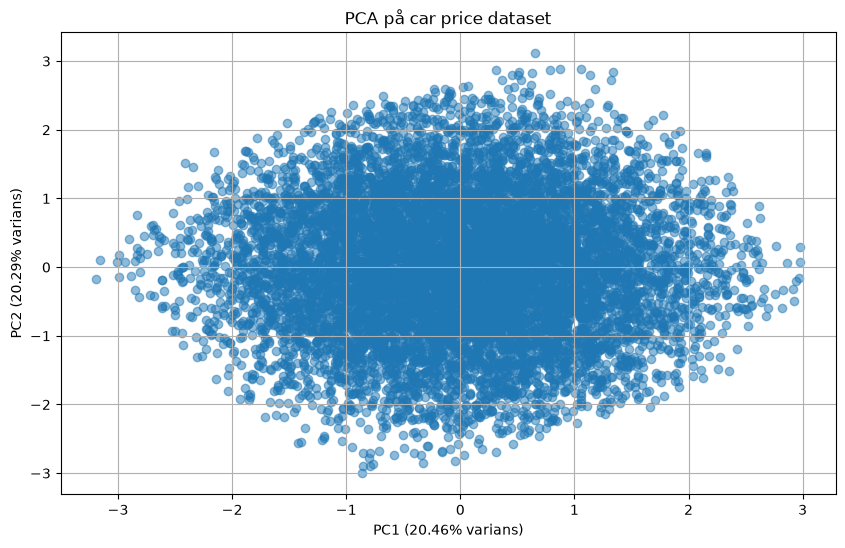

In [10]:
plt.figure(figsize=(10, 6))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], alpha=0.5)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} varians)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} varians)")
plt.title("PCA på car price dataset")
plt.grid()
plt.show()

## 6: Träna en modell på den reducerade datan och se om den gör en bättre eller sämre prediktioner

In [11]:
# Jämför resultat MED och UTAN PCA

# MED PCA:
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42
)

model_with_pca = LinearRegression()
model_with_pca.fit(X_train, y_train)
pred_with_pca = model_with_pca.predict(X_test)
error_with_pca = mean_squared_error(y_test, pred_with_pca)

print(f"\nFel MED PCA: {error_with_pca:.2f}")

# UTAN PCA:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

model_without_pca = LinearRegression()
model_without_pca.fit(X_train, y_train)
pred_without_pca = model_without_pca.predict(X_test)
error_without_pca = mean_squared_error(y_test, pred_without_pca)

print(f"Fel UTAN PCA: {error_without_pca:.2f}")


Fel MED PCA: 8634952.03
Fel UTAN PCA: 1137443.86


In [12]:
print("\nVilken är bättre?")

if error_with_pca < error_without_pca:
    print("Modellen fick lägre fel med PCA.")
else:
    print("Modellen fick högre fel med PCA.")


Vilken är bättre?
Modellen fick högre fel med PCA.
